# Bibliotekos

In [252]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

import importlib
import Lasso2
importlib.reload(Lasso2)
from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

# Duomenų paruošimas

In [253]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'absorbing_aerosol_index': [8],
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2],
    'stratospheric_NO2_column_number_density': [1, 3, 7],
    'NO2_slant_column_number_density': [1, 2],
    'tropopause_pressure': [1],
    'nmvoc': [1, 2],
    'nh3': [1, 11],
    'pm10': [1, 11],
    'sia': [11],
    'pans': [10],
    'dust': [1, 4],
    'pm2p5': [1, 11],
    'NO2': [1, 4, 9],

    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()
observation_times = data['observationTime'].copy()

drop_names = [
    'observationTime',
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [254]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,relativeHumidity_lag2,xgb_cloudCover_lag1,xgb_cloudCover_lag2,windSpeed_fixed_lag1,windSpeed_fixed_lag2,windSpeed_fixed_lag3,windGust_fixed_lag1,windGust_fixed_lag2,windDirection_fixed_lag4,windDirection_fixed_lag10
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,72.416667,53.916667,65.916667,0.879167,0.891667,2.462500,8.7,6.2,315.0,327.0
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,79.083333,46.541667,53.916667,1.495833,0.879167,0.891667,10.8,8.7,294.0,271.0
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,76.166667,82.583333,46.541667,1.270833,1.495833,0.879167,8.0,10.8,5.0,288.0
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,84.541667,83.478261,82.583333,0.645833,1.270833,1.495833,6.6,8.0,2.0,293.0
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,87.625000,69.708333,83.478261,1.270833,0.645833,1.270833,6.1,6.6,127.0,275.0


# SSA

In [255]:
# ── LeakFreeSSA: fits eigenvectors on train only ────────────────────────────

class LeakFreeSSA:
    """
    Singular Spectrum Analysis with strict separation of fit and transform.

    fit(train_series)
        Builds trajectory matrix from train only, computes eigenvectors U_.

    transform_train(train_series)
        Reconstructs all components for the training series.

    transform_test(train_series, test_series)
        For each test point, reconstructs using [train + test_so_far] context
        but projects onto the TRAIN eigenvectors only.
        Returns components of shape (n_components, len(test_series)).
    """

    def __init__(self, window_size: int = 10, n_components: int = 10):
        self.L = window_size
        self.n_components = n_components

    def _trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        """Build the (L × K) Hankel trajectory matrix."""
        K = len(series) - self.L + 1
        return np.array([series[i: i + self.L] for i in range(K)]).T  # (L, K)

    def fit(self, series: np.ndarray):
        """Compute and store eigenvectors from train series."""
        X = self._trajectory_matrix(series)          # (L, K)
        S = X @ X.T                                  # (L, L)
        eigenvalues, eigenvectors = np.linalg.eigh(S)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        self.U_ = eigenvectors[:, idx][:, :self.n_components]  # (L, n_comp)
        return self

    def _reconstruct(self, series: np.ndarray) -> np.ndarray:
        """Project series onto stored eigenvectors and diagonal-average back."""
        N = len(series)
        K = N - self.L + 1
        X = self._trajectory_matrix(series)          # (L, K)
        components = np.zeros((self.n_components, N))
        for i in range(self.n_components):
            u  = self.U_[:, i]                       # (L,)
            v  = u @ X                               # (K,)
            Xi = np.outer(u, v)                      # (L, K)
            comp  = np.zeros(N)
            count = np.zeros(N)
            for col in range(K):
                for row in range(self.L):
                    t = row + col
                    comp[t]  += Xi[row, col]
                    count[t] += 1
            components[i] = comp / count
        return components

    def transform_train(self, series: np.ndarray) -> np.ndarray:
        return self._reconstruct(series)

    def transform_test(self, train_series, test_series):
        N_test = len(test_series)
        result = np.zeros((self.n_components, N_test))
        
        for t in range(N_test):
            # Only use train + test up to and including day t
            context = np.concatenate([train_series, test_series[:t+1]])
            comps = self._reconstruct(context)
            # Take only the last value (today's reconstruction)
            result[:, t] = comps[:, -1]
        
        return result


# ── Exploratory SSA on the train series only (for visualisation) ─────────────
series_full_log = np.log1p(data['missforest_precipitation'].values)

L      = 10
N_COMP = 10

split_idx_explore = int(len(data) * 0.9)
train_series_explore = series_full_log[:split_idx_explore]

ssa_explore = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa_explore.fit(train_series_explore)
components = ssa_explore.transform_train(train_series_explore)

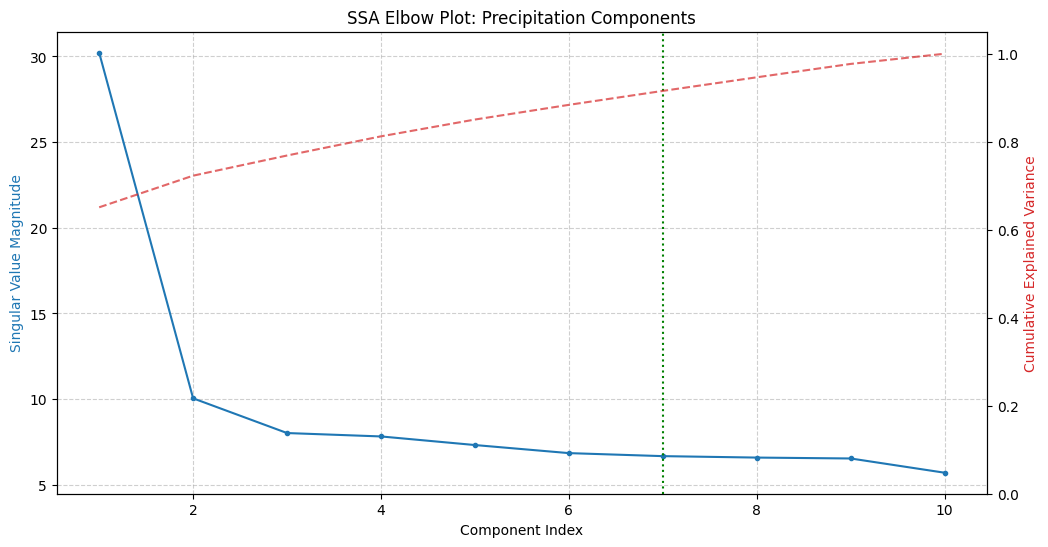

In [256]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

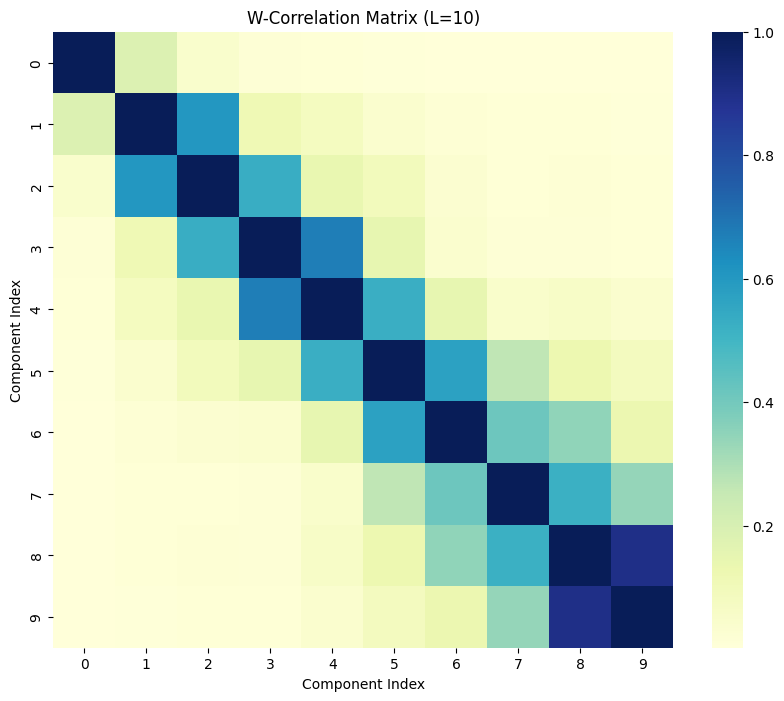

In [257]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

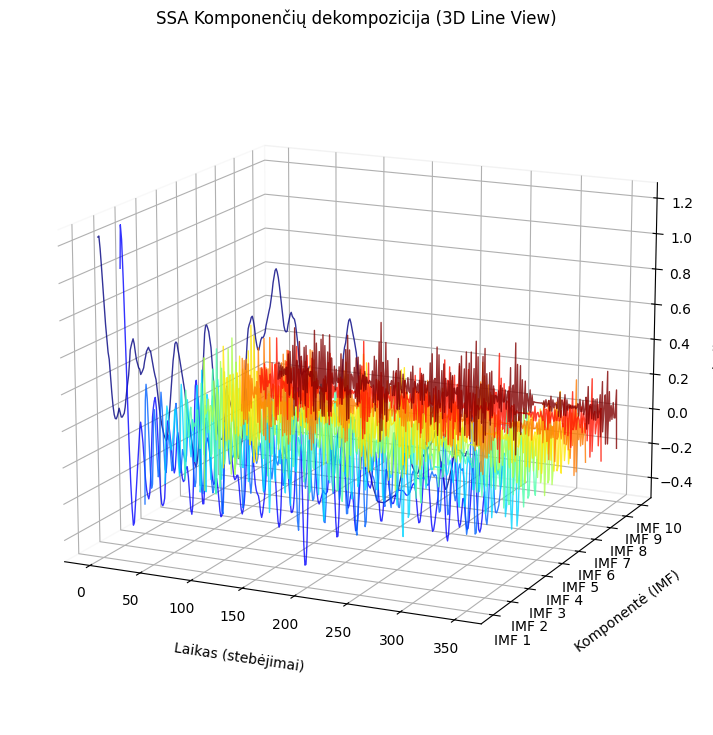

In [258]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(350, len(train_series_explore))
x = np.arange(n_points)
zs = np.arange(N_COMP)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, N_COMP))

for i in range(N_COMP):
    y = components[i][:n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

ax.view_init(elev=15, azim=-65)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.show()

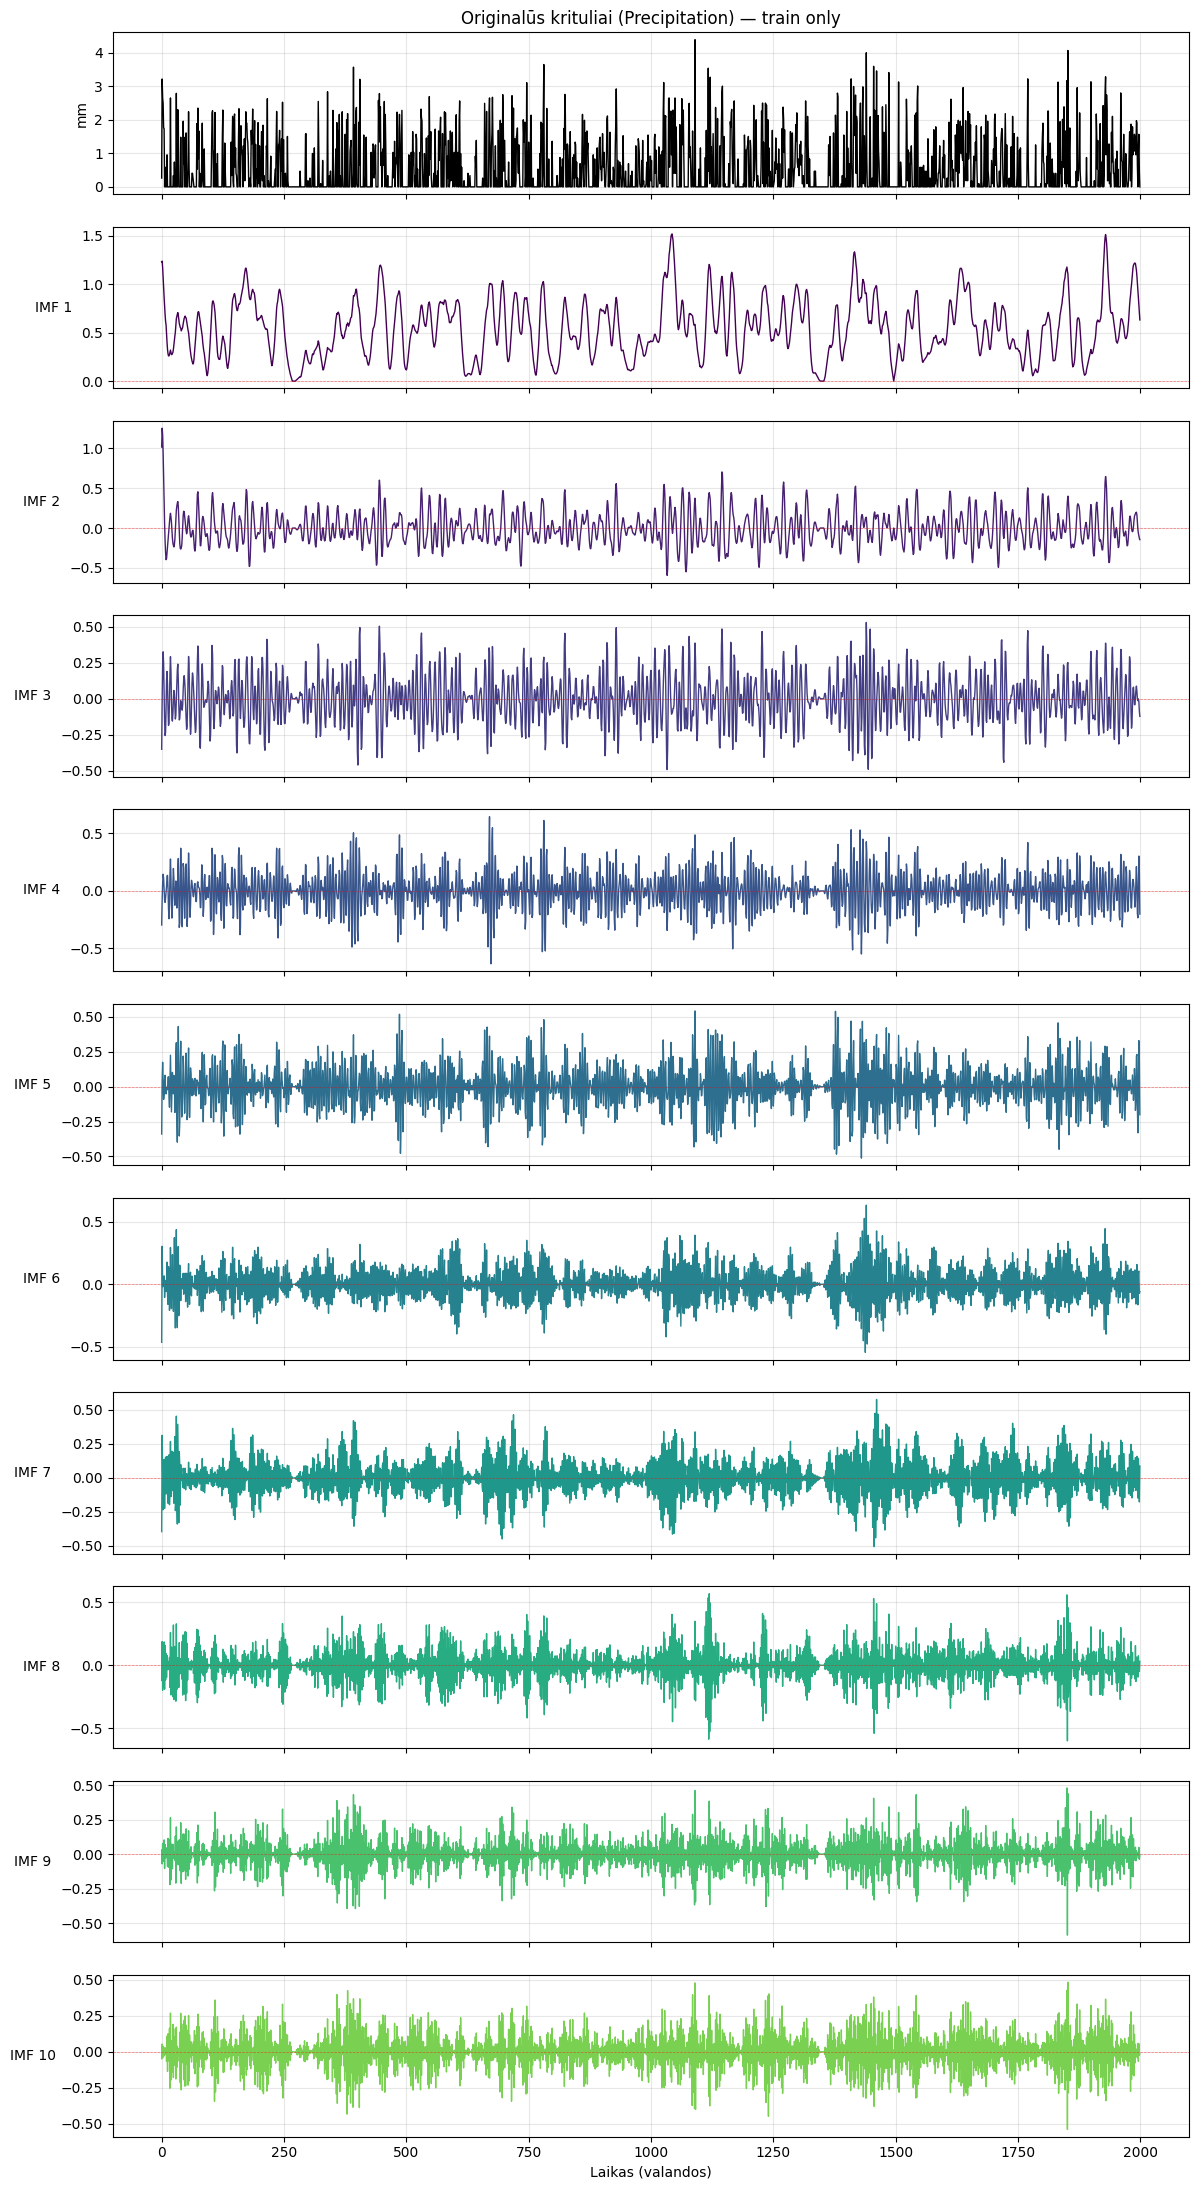

In [259]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

In [260]:
how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3],
    '5': [4],
    '6': [5],
    '7': [6],
    '8': [7, 8, 9],
}

# how_group = {
#     '1': [0],
#     '2': [1],
#     '3': [2],
#     '4': [3, 4],
#     '5': [5],
#     '6': [6, 7, 8, 9],
#     '7': [10, 11, 12],
#     '8': np.arange(13, 120, 1)
# }

# Build grouped components for the EXPLORATORY visualisation (train only)
grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

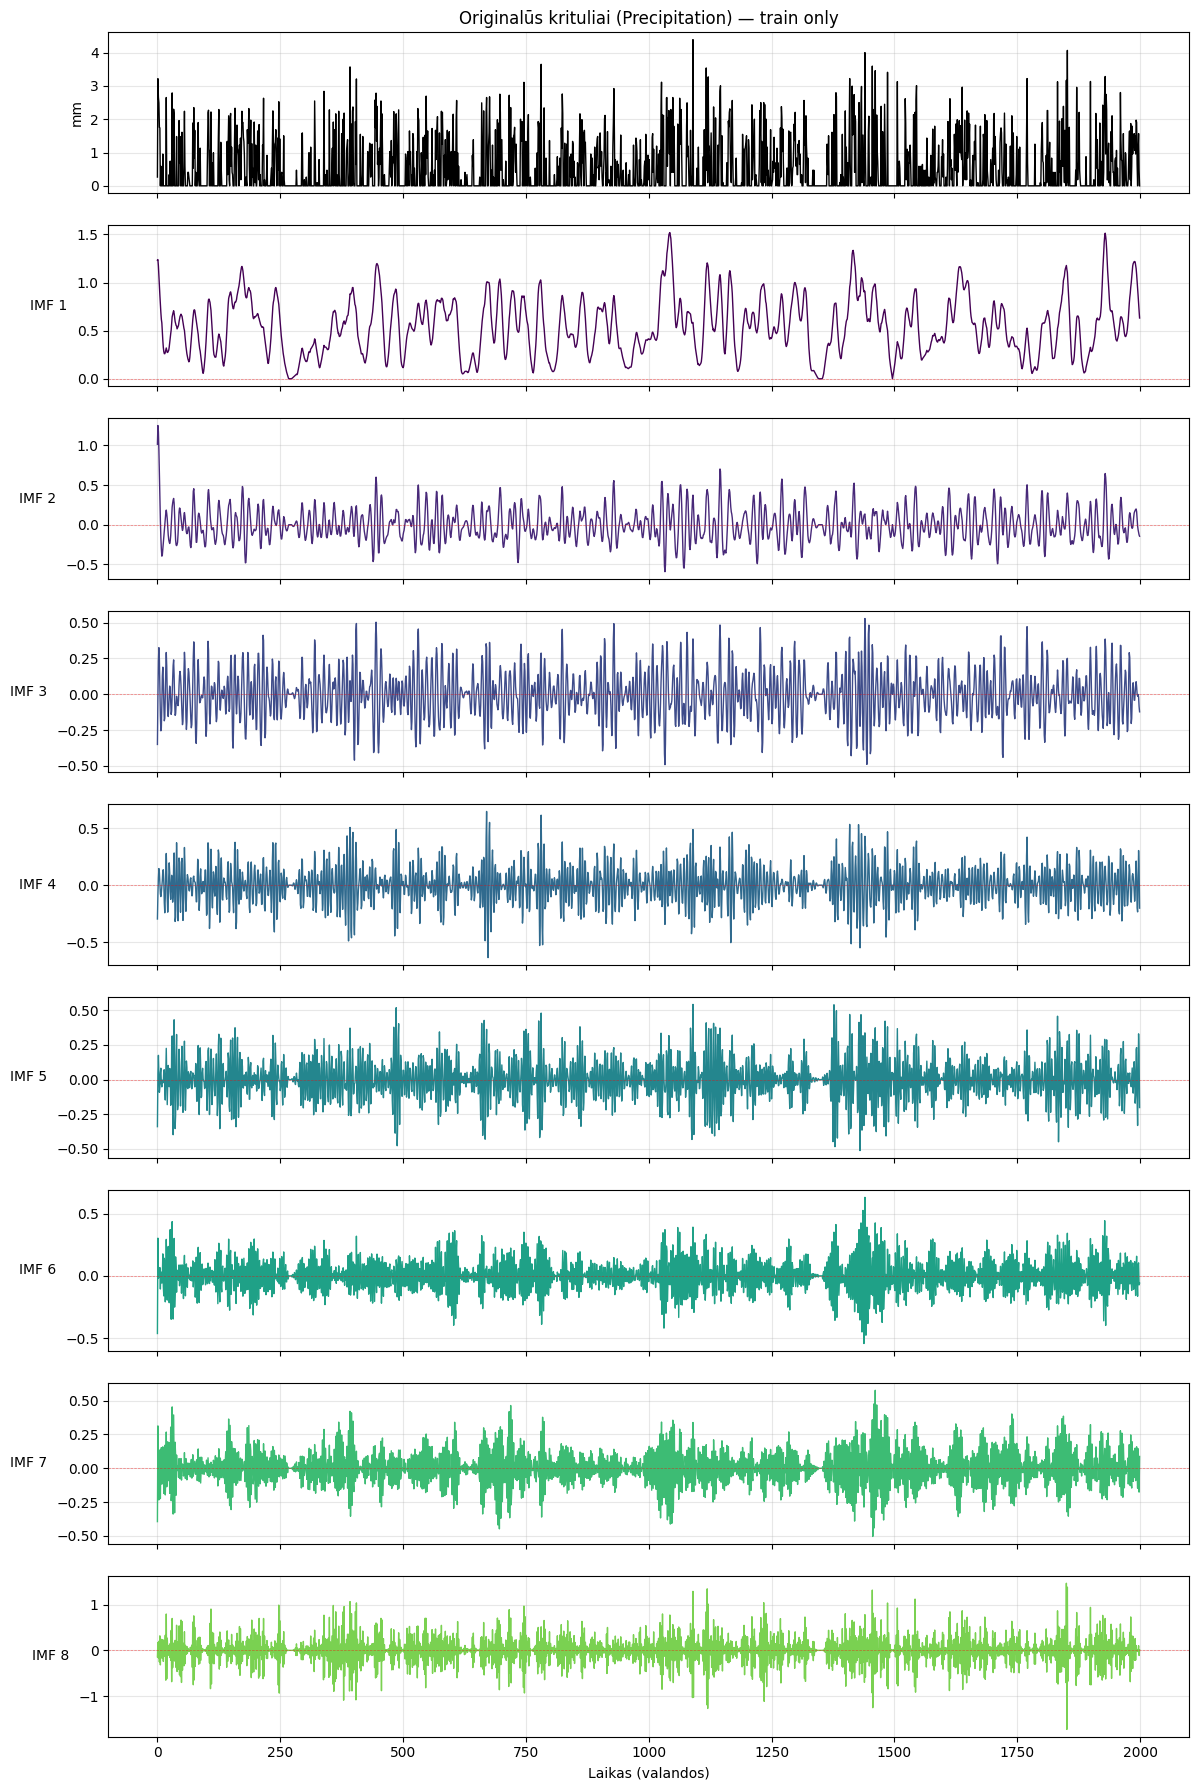

In [261]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

# SSA Mokymo testavimo aibės — leakage-free

## Skirstymas

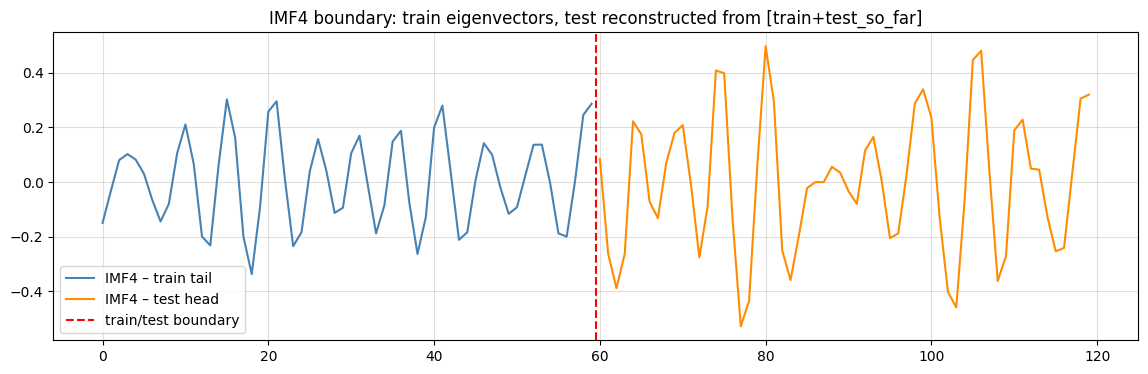

In [262]:
# ── 1. Split BEFORE any SSA ──────────────────────────────────────────────────
# split_idx = int(len(X) * 0.8)
split_idx = 2042

X_train_raw = X.iloc[:split_idx].copy()
X_test_raw  = X.iloc[split_idx:].copy()

# ── 2. Log-transform target series ───────────────────────────────────────────
train_series = np.log1p(X_train_raw['missforest_precipitation'].values)
test_series  = np.log1p(X_test_raw['missforest_precipitation'].values)

# ── 3. Fit SSA on TRAIN only ──────────────────────────────────────────────────
ssa = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa.fit(train_series)

# ── 4. Reconstruct components ─────────────────────────────────────────────────
#   Train: eigenvectors were fitted here — fully leak-free
#   Test : prepend full train for boundary context, project on TRAIN eigenvectors,
#          slice off only the test portion → no future values involved
train_components = ssa.transform_train(train_series)          # (N_COMP, N_train)
test_components  = ssa.transform_test(train_series,           # (N_COMP, N_test)
                                      test_series)

# ── 5. Group components into IMFs ─────────────────────────────────────────────
def make_grouped(components):
    grouped = []
    for key in how_group:
        new_comp = np.zeros(components.shape[1])
        for idx in how_group[key]:
            new_comp += components[idx]
        grouped.append(new_comp)
    return grouped

train_grouped = make_grouped(train_components)
test_grouped  = make_grouped(test_components)

# ── 6. Assign IMF columns back into the split DataFrames ─────────────────────
for i, key in enumerate(how_group):
    X_train_raw[f'IMF{i+1}'] = train_grouped[i]
    X_test_raw[f'IMF{i+1}']  = test_grouped[i]

# ── 7. Boundary sanity check ──────────────────────────────────────────────────
n_ctx = 60
plt.figure(figsize=(14, 4))
plt.plot(np.arange(n_ctx), train_grouped[3][-n_ctx:],
         linewidth=1.5, label='IMF4 – train tail', color='steelblue')
plt.plot(np.arange(n_ctx, 2*n_ctx), test_grouped[3][:n_ctx],
         linewidth=1.5, label='IMF4 – test head', color='darkorange')
plt.axvline(x=n_ctx - 0.5, color='red', linestyle='--', label='train/test boundary')
plt.title('IMF4 boundary: train eigenvectors, test reconstructed from [train+test_so_far]')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

In [263]:
def rolling_window_fun(column_name, window_value, data):
    new_col_name = f"{column_name}_mean_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean()

def rolling_max(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).max()

def rolling_min(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).min()

In [264]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week',
       'month_sin', 'month_cos', 'absorbing_aerosol_index_lag8',
       'H2O_column_number_density_lag1', 'NO2_column_number_density_lag1',
       'NO2_column_number_density_lag2',
       'stratospheric_NO2_column_number_density_lag1',
       'stratospheric_NO2_column_number_density_lag3',
       'stratospheric_NO2_column_number_density_lag7',
       'NO2_slant_column_n

In [265]:
window_info = {
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [3, 2],
    'stratospheric_NO2_column_number_density': [3, 5, 7],
    'NO2_slant_column_number_density': [2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [2],
    'NO2': [3, 5, 7],
    'dust': [4, 6, 8],
    'sia': [11],
    'pm2p5': [11],
    'pans': [10],
    'nmvoc': [3, 5],
    'nh3': [2, 4],
    'pm10': [5]
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_window_fun(col, window, df)
        else:
            rolling_window_fun(col, windows, df)

window_info = {
    'airTemperature': [7],
    'relativeHumidity': [7],
    'seaLevelPressure': [7],
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_max(col, window, df)
        else:
            rolling_max(col, windows, df)

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_min(col, window, df)
        else:
            rolling_min(col, windows, df)

all_data = pd.concat([X_train_raw, X_test_raw])

for i in range(1, 9):
    all_data[f'IMF{i}_diff'] = all_data[f'IMF{i}'].diff()

X_train_raw = all_data.iloc[:len(X_train_raw)].copy().dropna()
X_test_raw = all_data.iloc[len(X_train_raw):].copy()

X_train_raw = X_train_raw.dropna()
X_test_raw  = X_test_raw.dropna()

In [266]:
IMF_COLS = ['IMF1', 'IMF2', 'IMF3_diff', 'IMF4_diff', 'IMF5', 'IMF6_diff', 'IMF7', 'IMF8']
IMF_COLS_true = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']

y_train = X_train_raw[IMF_COLS]
y_test  = X_test_raw[IMF_COLS]
y_original_imf = X_test_raw[IMF_COLS_true]

In [267]:
# Predict next day: X[t] → y[t+1]
# X_train = X_train_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_train = y_train.iloc[1:]

X_train = X_train_raw[:].drop(columns=['observationTime'], errors='ignore')
y_train = y_train.iloc[:]

In [268]:
# X_test = X_test_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_test = y_test.iloc[1:]

X_test = X_test_raw[:].drop(columns=['observationTime'], errors='ignore')
y_test = y_test.iloc[:]

In [269]:
# Scaler fitted on TRAIN only, applied to both
sklearn.set_config(transform_output="pandas")
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

## IMF1

In [270]:
featues_imf1 = select_features_lasso(X_train, 'IMF1', 0.001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 5
Geriausias lambda (alpha): 0.0010
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_lag3', 'relativeHumidity', 'stratospheric_NO2_column_number_density_mean_5', 'pm2p5_lag1', 'absorbing_aerosol_index_lag8', 'pm10_mean_5', 'relativeHumidity_lag2', 'pm10', 'sia_mean_11', 'feelsLikeTemperature_fixed', 'BrO_Error', 'windDirection_fixed_lag4', 'absorbing_aerosol_index', 't2m', 'pans_lag10', 'BrO', 'H2O_column_number_density', 'windGust_fixed_lag1', 'dust_mean_8', 'sia_lag11', 'IMF7_diff', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'IMF3_diff', 'NO2_slant_column_number_density', 'month_cos', 'windDirection_fixed', 'nmvoc_mean_3', 'stratospheric_NO2_column_number_density_mean_3', 'nmvoc', 'missforest_precipitation', 'IMF5_diff', 'NO2_slant_column_number_density_mean_2', 'windSpeed_fixed', 'tropopause_pressure_mean_1', 'xgb_cloudCover_lag1', 'windSpeed_fixed_lag2', 'NO2_lag4', 'IMF6', 'windGus

In [271]:
featues_imf1.extend(['tp', 'missforest_precipitation'])
X_train_IMF1 = X_train[featues_imf1]
X_test_IMF1 = X_test[featues_imf1]

## IMF2

In [272]:
featues_imf2 = select_features_lasso(X_train, 'IMF2', 0.001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 13
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_lag3', 'relativeHumidity', 'stratospheric_NO2_column_number_density_mean_5', 'pm2p5_lag1', 'absorbing_aerosol_index_lag8', 'pm10_mean_5', 'relativeHumidity_lag2', 'pm10', 'feelsLikeTemperature_fixed', 'BrO_Error', 'windDirection_fixed_lag4', 'absorbing_aerosol_index', 't2m', 'BrO', 'H2O_column_number_density', 'windGust_fixed_lag1', 'dust_mean_8', 'sia_lag11', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'NO2_slant_column_number_density', 'month_cos', 'windDirection_fixed', 'nmvoc_mean_3', 'stratospheric_NO2_column_number_density_mean_3', 'nmvoc', 'missforest_precipitation', 'NO2_slant_column_number_density_mean_2', 'windSpeed_fixed', 'tropopause_pressure_mean_1', 'xgb_cloudCover_lag1', 'windSpeed_fixed_lag2', 'NO2_lag4', 'windGust_fixed', 'xgb_cloudCover', 'NO2_slant_column_number_density_lag2', 'nh3_la

In [273]:
X_train_IMF2 = X_train[featues_imf2]
X_test_IMF2 = X_test[featues_imf2]

## IMF3

In [274]:
featues_imf3 = select_features_lasso(X_train, 'IMF3_diff', 0.00001)

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 14
Geriausias lambda (alpha): 0.0016
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_lag3', 'relativeHumidity', 'stratospheric_NO2_column_number_density_mean_5', 'pm2p5_lag1', 'pm10_mean_5', 'relativeHumidity_lag2', 'pm10', 'sia_mean_11', 'feelsLikeTemperature_fixed', 'BrO_Error', 'windDirection_fixed_lag4', 'absorbing_aerosol_index', 't2m', 'pans_lag10', 'BrO', 'H2O_column_number_density', 'windGust_fixed_lag1', 'dust_mean_8', 'sia_lag11', 'IMF7_diff', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'NO2_slant_column_number_density', 'month_cos', 'nmvoc_mean_3', 'stratospheric_NO2_column_number_density_mean_3', 'nmvoc', 'missforest_precipitation', 'IMF5_diff', 'NO2_slant_column_number_density_mean_2', 'windSpeed_fixed', 'tropopause_pressure_mean_1', 'xgb_cloudCover_lag1', 'windSpeed_fixed_lag2', 'IMF1_diff', 'IMF6', 'windGust_fixed', 'xgb_cloudCover', 'NO2_slant_column_number_density_lag2'

In [275]:
X_train_IMF3 = X_train[featues_imf3]
X_test_IMF3 = X_test[featues_imf3]

## IMF4

In [276]:
featues_imf4 = select_features_lasso(X_train, 'IMF4_diff', -0.000000001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 105
Geriausias lambda (alpha): 0.0014
Pašalinti požymiai: ['IMF2', 'IMF8', 'month', 'windDirection_fixed_lag10', 'absorbing_aerosol_index_lag8', 'NO2_lag4', 'IMF7', 'IMF2_diff', 'IMF4', 'IMF6_diff', 'IMF5', 'windDirection_fixed', 'O3_Error', 'day_of_week']


In [277]:
X_train_IMF4 = X_train[featues_imf4]
X_test_IMF4 = X_test[featues_imf4]

## IMF5

In [278]:
featues_imf5 = select_features_lasso(X_train, 'IMF5')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 13
Geriausias lambda (alpha): 0.0021
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_lag3', 'relativeHumidity', 'stratospheric_NO2_column_number_density_mean_5', 'pm2p5_lag1', 'pm10_mean_5', 'relativeHumidity_lag2', 'pm10', 'sia_mean_11', 'feelsLikeTemperature_fixed', 'BrO_Error', 'windDirection_fixed_lag4', 'absorbing_aerosol_index', 't2m', 'pans_lag10', 'BrO', 'H2O_column_number_density', 'windGust_fixed_lag1', 'dust_mean_8', 'sia_lag11', 'IMF7_diff', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'IMF3_diff', 'NO2_slant_column_number_density', 'month_cos', 'nmvoc_mean_3', 'stratospheric_NO2_column_number_density_mean_3', 'nmvoc', 'missforest_precipitation', 'NO2_slant_column_number_density_mean_2', 'windSpeed_fixed', 'tropopause_pressure_mean_1', 'xgb_cloudCover_lag1', 'windSpeed_fixed_lag2', 'IMF1_diff', 'IMF6', 'windGust_fixed', 'xgb_cloudCover', 'NO2_slant_column_number_density_lag2'

In [279]:
X_train_IMF5 = X_train[featues_imf5]
X_test_IMF5 = X_test[featues_imf5]

## IMF6

In [280]:
featues_imf6 = select_features_lasso(X_train, 'IMF6_diff')

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 26
Geriausias lambda (alpha): 0.0018
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_lag3', 'relativeHumidity', 'stratospheric_NO2_column_number_density_mean_5', 'absorbing_aerosol_index_lag8', 'pm10_mean_5', 'relativeHumidity_lag2', 'pm10', 'sia_mean_11', 'feelsLikeTemperature_fixed', 'BrO_Error', 'windDirection_fixed_lag4', 't2m', 'BrO', 'windGust_fixed_lag1', 'dust_mean_8', 'sia_lag11', 'IMF7_diff', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'NO2_slant_column_number_density', 'month_cos', 'windDirection_fixed', 'nmvoc_mean_3', 'stratospheric_NO2_column_number_density_mean_3', 'missforest_precipitation', 'NO2_slant_column_number_density_mean_2', 'windSpeed_fixed', 'xgb_cloudCover_lag1', 'NO2_lag4', 'IMF6', 'windGust_fixed', 'xgb_cloudCover', 'NO2_slant_column_number_density_lag2', 'nh3_lag1', 'relativeHumidity_lag1', 'pans_mean_10', 'nmvoc_lag1', 'tropopause_pressure_lag1', 'airTempe

In [281]:
X_train_IMF6 = X_train[featues_imf6]
X_test_IMF6 = X_test[featues_imf6]

## IMF7

In [282]:
featues_imf7 = select_features_lasso(X_train, 'IMF7', -0.000001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 87
Geriausias lambda (alpha): 0.0035
Pašalinti požymiai: ['pans', 'airTemperature_lag9', 'absorbing_aerosol_index_lag8', 'relativeHumidity_lag2', 'IMF2_diff', 'pm10', 'feelsLikeTemperature_fixed', 'windDirection_fixed_lag4', 'sia', 'windGust_fixed_lag1', 'windGust_fixed_lag2', 'IMF3_diff', 'NO2_column_number_density_lag2', 'IMF5', 'NO2_slant_column_number_density', 'IMF7', 'NO2_column_number_density_lag1', 'nh3', 'missforest_precipitation', 'IMF5_diff', 'IMF4_diff', 'O3_Error', 'xgb_cloudCover', 'NO2_slant_column_number_density_lag2', 'relativeHumidity_lag1', 'xgb_cloudCover_lag2', 'IMF1', 'nmvoc_lag1', 'tropopause_pressure_lag1', 'IMF8', 'pm2p5', 'seaLevelPressure_max_7']


In [283]:
X_train_IMF7 = X_train[featues_imf7]
X_test_IMF7 = X_test[featues_imf7]

## IMF8

In [284]:
featues_imf8 = select_features_lasso(X_train, 'IMF8')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 31
Geriausias lambda (alpha): 0.0014
Pašalinti požymiai: ['NO2_Error', 'stratospheric_NO2_column_number_density_mean_5', 'absorbing_aerosol_index_lag8', 'relativeHumidity_lag2', 'sia_mean_11', 'windDirection_fixed_lag4', 'windGust_fixed_lag1', 'sia_lag11', 'H2O_column_number_density_mean_2', 'windGust_fixed_lag2', 'NO2_slant_column_number_density', 'stratospheric_NO2_column_number_density_mean_3', 'missforest_precipitation', 'IMF5_diff', 'windSpeed_fixed', 'tropopause_pressure_mean_1', 'nmvoc_lag1', 'dust', 'NO2_lag9', 'pm2p5_mean_11', 'seaLevelPressure_max_7', 'airTemperature_lag9', 'dust_lag4', 'IMF2_diff', 'month_sin', 'sia', 'IMF2', 'NO2_column_number_density_lag2', 'IMF5', 'nh3', 'airTemperature_lag1', 'stratospheric_NO2_column_number_density_lag1', 'nh3_mean_2', 'O3_Error', 'NO2_mean_5', 'xgb_cloudCover_lag2', 'IMF1', 'pm2p5', 'IMF3', 'pm10_lag11', 'airTemperature_max_7', 'dust_mean_8', 'airTemperature', 'stratospheric_NO

In [285]:
X_train_IMF8 = X_train[featues_imf8]
X_test_IMF8 = X_test[featues_imf8]

# LSTM

In [286]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [287]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()
        # self.scaler = MinMaxScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [288]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [289]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        torch.manual_seed(42)
        np.random.seed(42)
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=5)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

In [290]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 1}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

In [291]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [292]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0415        0.0255     +  0.4545
      2        0.0167        0.0151     +  0.2109
      3        0.0116        0.0094     +  0.1999
      4        0.0088        0.0078     +  0.2138
      5        0.0074        0.0062     +  0.2160
      6        0.0061        0.0049     +  0.2112
      7        0.0048        0.0038     +  0.2169
      8        0.0043        0.0031     +  0.2117
      9        0.0040        0.0027     +  0.2143
     10        0.0036        0.0025     +  0.2167
     11        0.0028        0.0021     +  0.2074
     12        0.0029        0.0020     +  0.1995
     13        0.0027        0.0019     +  0.2003
     14        0.0023        0.0018     +  0.2048
     15        0.0023        0.0019        0.2002
     16        0.0021        0.0016     +  0.1974
     17        0.0019        0.0016        0.1918
     18        0.0017        0.0016        0.1970


In [194]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.005],
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1199        0.0833     +  0.1144
      2        0.0340        0.0226     +  0.1158
      3        0.0149        0.0171     +  0.1041
      4        0.0114        0.0145     +  0.0923
      5        0.0096        0.0128     +  0.0974
      6        0.0087        0.0117     +  0.0921
      7        0.0079        0.0110     +  0.0896
      8        0.0073        0.0105     +  0.0929
      9        0.0067        0.0100     +  0.0907
     10        0.0062        0.0096     +  0.0883
     11        0.0057        0.0092     +  0.1036
     12        0.0052        0.0089     +  0.0802
     13        0.0048        0.0085     +  0.0780
     14        0.0044        0.0082     +  0.0797
     15        0.0040        0.0079     +  0.0757
     16        0.0037        0.0075     +  0.0834
     17        0.0033        0.0072    

In [293]:
y_true = y_test['IMF1'].values.astype(float)
# y_true = np.expm1(y_true)

y_true =  y_true[14:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true[:]
y_pred_IMF1 = y_pred[:]


RMSE:     0.1865
MAE:      0.1452
R2:       0.6832
Spearman: 0.8786


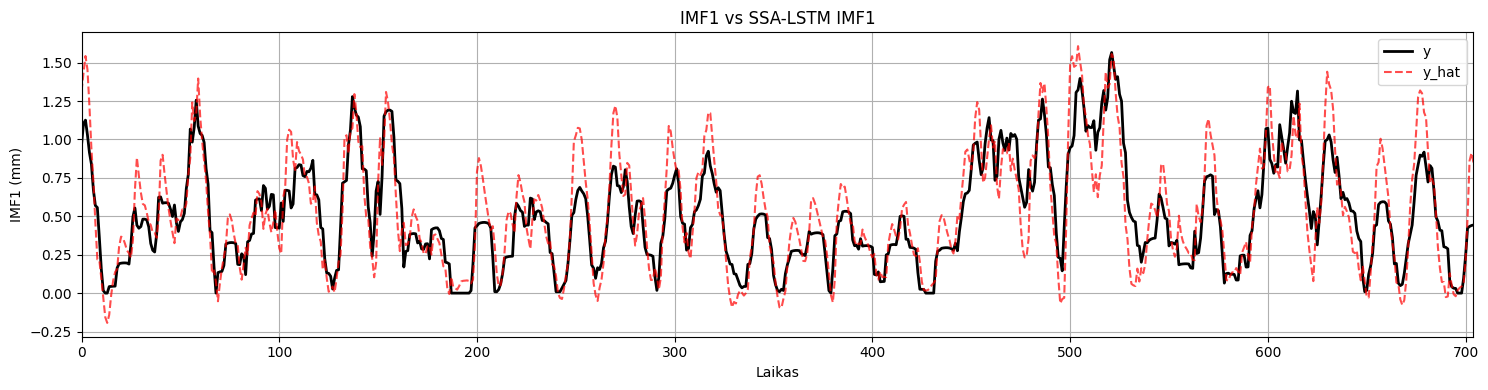

In [294]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9854


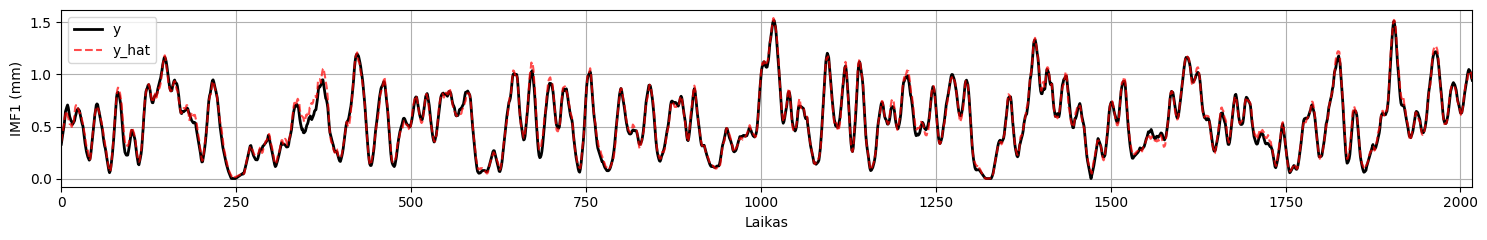

In [295]:
IMF1_fit = pipeline.predict(X_train_IMF1.values)
print(f"R2: {r2_score(y_train['IMF1'][14:], IMF1_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF1'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF1_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF1_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7} R2:       0.3472

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

In [296]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=10,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [297]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0071        0.0026     +  0.3162
      2        0.0026        0.0009     +  0.1004
      3        0.0014        0.0006     +  0.0942
      4        0.0006        0.0004     +  0.0946
      5        0.0004        0.0003     +  0.1141
      6        0.0003        0.0003     +  0.1056
      7        0.0002        0.0002     +  0.0894
      8        0.0002        0.0002     +  0.0910
      9        0.0002        0.0002     +  0.0955
     10        0.0001        0.0002     +  0.0951
     11        0.0001        0.0002     +  0.0973
     12        0.0001        0.0002     +  0.0976
     13        0.0001        0.0002     +  0.0956
     14        0.0001        0.0001     +  0.0969
     15        0.0001        0.0002        0.1017
     16        0.0001        0.0001     +  0.1033
     17        0.0001        0.0002        0.1016
     18        0.0003        0.0003        0.1015


In [203]:
param_grid = {
    'window_size': [1, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0122        0.0102     +  0.1202
      2        0.0063        0.0074     +  0.1055
      3        0.0045        0.0060     +  0.1188
      4        0.0037        0.0056     +  0.0958
      5        0.0032        0.0054     +  0.0877
      6        0.0029        0.0053     +  0.0884
      7        0.0027        0.0052     +  0.0931
      8        0.0025        0.0051     +  0.0808
      9        0.0023        0.0050     +  0.0815
     10        0.0021        0.0050     +  0.0777
     11        0.0020        0.0050     +  0.0780
     12        0.0019        0.0050     +  0.0793
     13        0.0017        0.0050        0.0745
     14        0.0016        0.0050        0.0729
     15        0.0016        0.0050        0.0739
     16        0.0015        0.0051        0.0772
     17        0.0014        0.0052    

In [298]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[10:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true[4:]
y_pred_IMF2 = y_pred[4:]

RMSE:     0.2281
MAE:      0.1698
R2:       0.5495
Spearman: 0.7650


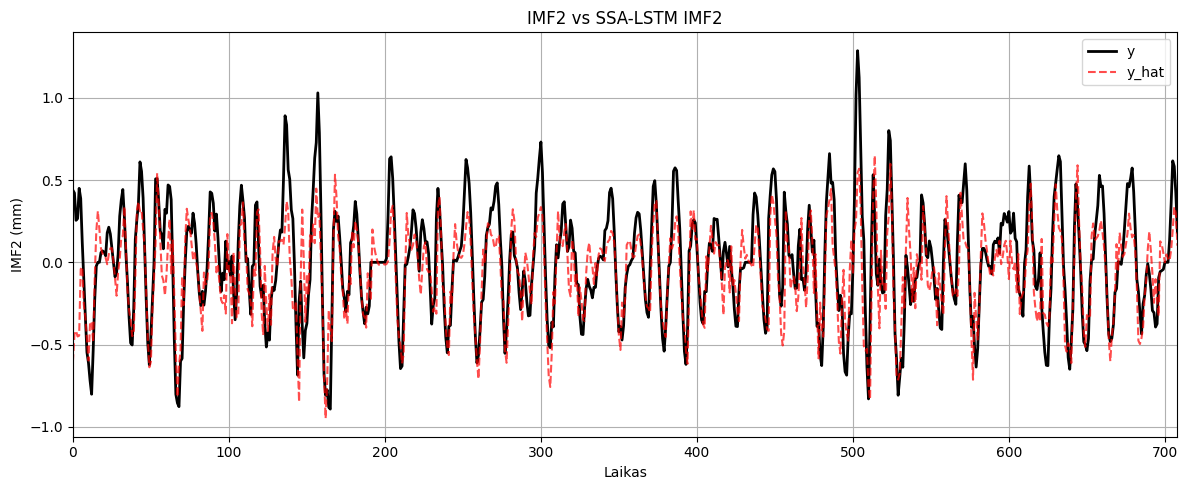

In [299]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9958


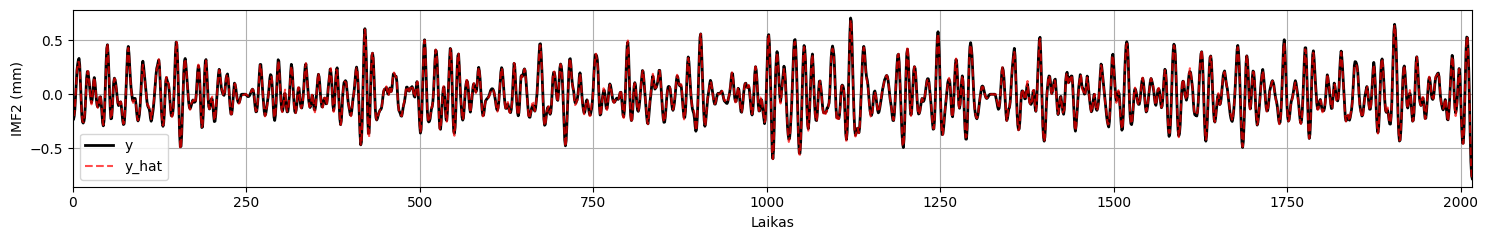

In [300]:
IMF2_fit = pipeline.predict(X_train_IMF2.values)[4:]
print(f"R2: {r2_score(y_train['IMF2'][14:], IMF2_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF2'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF2_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF2_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

In [301]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [302]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3_diff'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0038        0.0010     +  0.3041
      2        0.0008        0.0004     +  0.1614
      3        0.0005        0.0003     +  0.1429
      4        0.0005        0.0003     +  0.1418
      5        0.0005        0.0003        0.1209
      6        0.0004        0.0005        0.1289
      7        0.0004        0.0003     +  0.1246
      8        0.0003        0.0002     +  0.1402
      9        0.0002        0.0002     +  0.1250
     10        0.0002        0.0001     +  0.1365
     11        0.0002        0.0002        0.1426
     12        0.0002        0.0002        0.1424
     13        0.0002        0.0001        0.1269
     14        0.0002        0.0002        0.1269
     15        0.0002        0.0001     +  0.1405
     16        0.0002        0.0001        0.1423
     17        0.0001        0.0001        0.1404
     18        0.0001        0.0001     +  0.1410


In [474]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.3, 0.4],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0181        0.0075     +  0.1272
      2        0.0046        0.0033     +  0.1208
      3        0.0022        0.0027     +  0.1090
      4        0.0016        0.0020     +  0.0959
      5        0.0014        0.0018     +  0.0850
      6        0.0012        0.0018        0.0808
      7        0.0010        0.0018     +  0.0780
      8        0.0010        0.0013     +  0.0749
      9        0.0009        0.0018        0.0801
     10        0.0007        0.0014        0.0770
     11        0.0010        0.0017        0.0779
     12        0.0014        0.0022        0.0770
     13        0.0015        0.0014        0.0858
     14        0.0007        0.0013     +  0.0799
     15        0.0004        0.0010     +  0.0748
     16        0.0002        0.0009     +  0.0774
     17        0.0002        0.0008    

In [303]:
y_true = y_test['IMF3_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true[9:]
y_pred_IMF3 = y_pred[9:]

RMSE:     0.1965
MAE:      0.1513
R2:       0.1825
Spearman: 0.3919


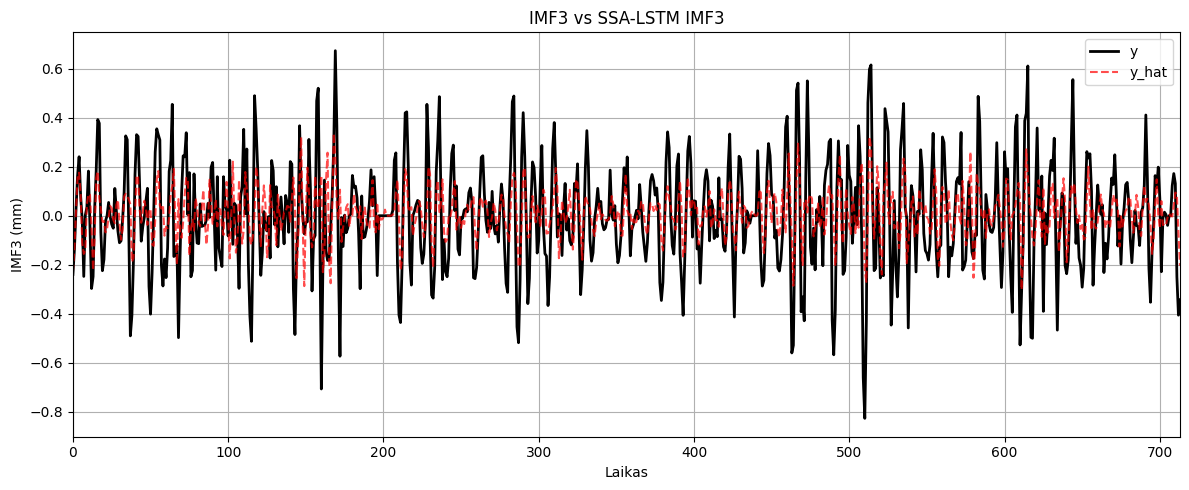

In [304]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

32 0.1 128 2 5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

In [305]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=12, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [306]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0157        0.0133     +  0.4655
      2        0.0134        0.0139        0.2770
      3        0.0114        0.0136        0.2377
      4        0.0109        0.0139        0.2177
      5        0.0090        0.0099     +  0.2324
      6        0.0076        0.0118        0.2170
      7        0.0069        0.0073     +  0.2206
      8        0.0060        0.0077        0.2328
      9        0.0042        0.0078        0.2263
     10        0.0039        0.0088        0.2196
     11        0.0040        0.0090        0.2417
     12        0.0037        0.0068     +  0.2320
     13        0.0037        0.0072        0.2369
     14        0.0030        0.0080        0.2282
     15        0.0029        0.0067     +  0.2144
     16        0.0020        0.0062     +  0.2088
     17        0.0016        0.0064        0.2048
     18        0.0013        0.0070        0.2089


In [140]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0154        0.0129     +  0.3656
      2        0.0107        0.0123     +  0.2498
      3        0.0119        0.0121     +  0.2100
      4        0.0096        0.0139        0.1943
      5        0.0083        0.0103     +  0.1786
      6        0.0054        0.0104        0.1540
      7        0.0050        0.0159        0.1594
      8        0.0056        0.0107        0.1433
      9        0.0043        0.0088     +  0.1438
     10        0.0027        0.0156        0.1383
     11        0.0043        0.0167        0.1436
     12        0.0047        0.0106        0.1691
     13        0.0026        0.0099        0.1693
     14        0.0025        0.0106        0.1623
     15        0.0040        0.0092        0.1598
     16        0.0019        0.0122        0.1556
     17        0.0021        0.0090    

In [307]:
y_true = y_test['IMF4_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.3088
MAE:      0.2287
R2:       -0.0710
Spearman: 0.1949


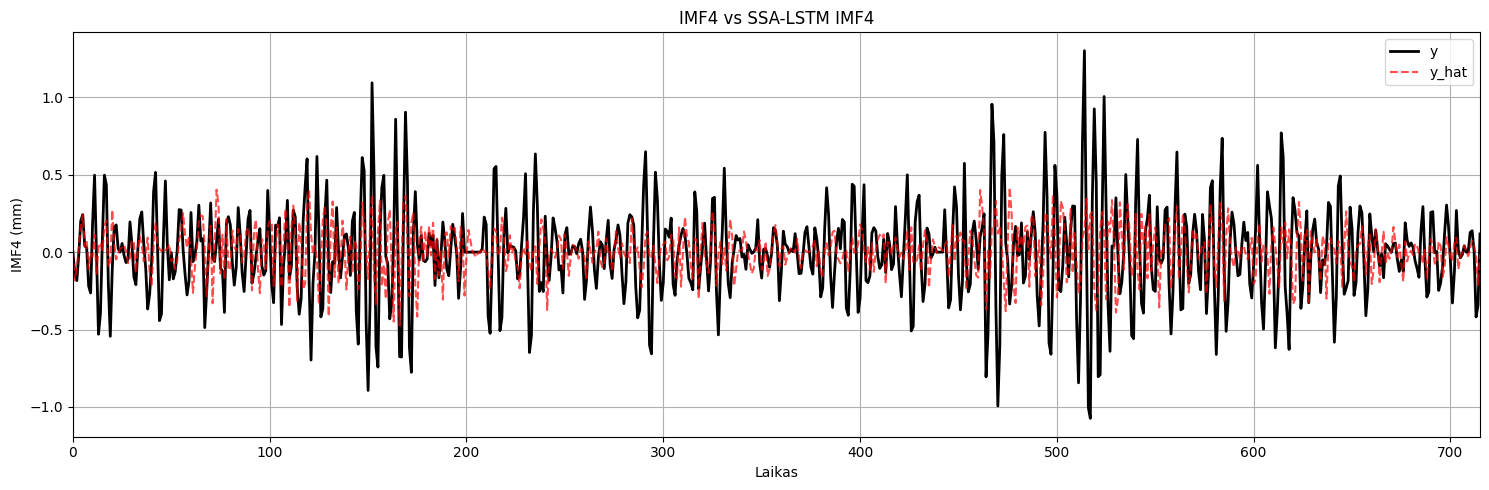

In [308]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 64, 'module__num_layers': 2, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 2}

In [309]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=2,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [310]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0082        0.0036     +  0.3327
      2        0.0026        0.0010     +  0.1223
      3        0.0011        0.0008     +  0.1160
      4        0.0009        0.0008        0.1026
      5        0.0010        0.0008     +  0.1137
      6        0.0009        0.0007     +  0.1099
      7        0.0009        0.0008        0.1145
      8        0.0009        0.0008        0.1133
      9        0.0008        0.0008        0.1043
     10        0.0009        0.0008        0.1185
     11        0.0009        0.0008        0.1221
     12        0.0009        0.0008        0.1153
     13        0.0009        0.0008        0.1307
     14        0.0009        0.0008        0.1307
     15        0.0009        0.0007        0.1157
     16        0.0008        0.0007     +  0.1086
     17        0.0008        0.0007        0.1121
     18        0.0008        0.0008        0.1319


In [182]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 216 candidates, totalling 432 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0130        0.0087     +  0.0741
      2        0.0045        0.0050     +  0.0646
      3        0.0026        0.0036     +  0.0658
      4        0.0018        0.0028     +  0.0617
      5        0.0013        0.0022     +  0.0636
      6        0.0010        0.0019     +  0.0717
      7        0.0007        0.0016     +  0.0824
      8        0.0006        0.0014     +  0.0679
      9        0.0005        0.0013     +  0.0628
     10        0.0004        0.0012     +  0.0658
     11        0.0003        0.0011     +  0.0681
     12        0.0002        0.0010     +  0.0680
     13        0.0002        0.0009     +  0.0660
     14        0.0002        0.0009     +  0.0654
     15        0.0001        0.0009     +  0.0603
     16        0.0001        0.0008     +  0.0642
     17        0.0001        0.0008  

In [311]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[2:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true[12:]
y_pred_IMF5 = y_pred[12:]

RMSE:     0.2540
MAE:      0.1878
R2:       0.4609
Spearman: 0.6608


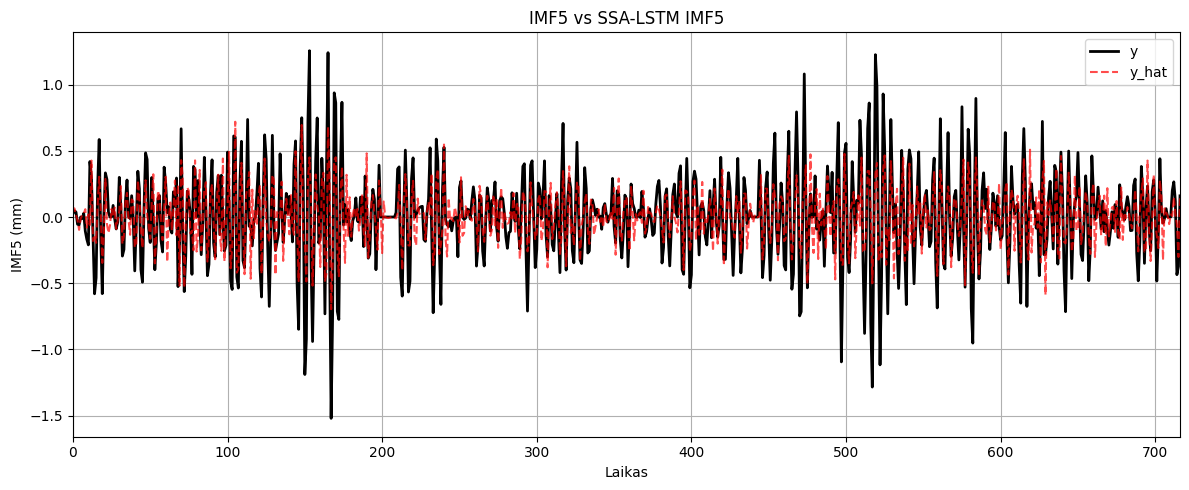

In [312]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [313]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [314]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6_diff'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0139        0.0110     +  0.5237
      2        0.0059        0.0037     +  0.2768
      3        0.0034        0.0031     +  0.2621
      4        0.0025        0.0025     +  0.2513
      5        0.0026        0.0023     +  0.2462
      6        0.0020        0.0014     +  0.2485
      7        0.0021        0.0029        0.2712
      8        0.0019        0.0017        0.2469
      9        0.0017        0.0017        0.2487
     10        0.0015        0.0012     +  0.2726
     11        0.0013        0.0016        0.2435
     12        0.0014        0.0020        0.2379
     13        0.0013        0.0015        0.2458
     14        0.0015        0.0019        0.2481
     15        0.0016        0.0020        0.2732
     16        0.0015        0.0018        0.2549
     17        0.0013        0.0020        0.2460
     18        0.0015        0.0017        0.2498


In [358]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0059        0.0123     +  0.2502
      2        0.0121        0.0113     +  0.2480
      3        0.0045        0.0031     +  0.1873
      4        0.0023        0.0022     +  0.1742
      5        0.0016        0.0018     +  0.1487
      6        0.0009        0.0015     +  0.1461
      7        0.0007        0.0013     +  0.1444
      8        0.0006        0.0012     +  0.1406
      9        0.0005        0.0013        0.1378
     10        0.0004        0.0013        0.1377
     11        0.0004        0.0012     +  0.1375
     12        0.0003        0.0011     +  0.1412
     13        0.0003        0.0017        0.1433
     14        0.0005        0.0027        0.1594
     15        0.0006        0.0013        0.1500
     16        0.0006        0.0027        0.1554
     17        0.0011        0.0021    

In [315]:
y_true = y_test['IMF6_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true[7:]
y_pred_IMF6 = y_pred[7:]

RMSE:     0.4085
MAE:      0.3006
R2:       0.3900
Spearman: 0.6131


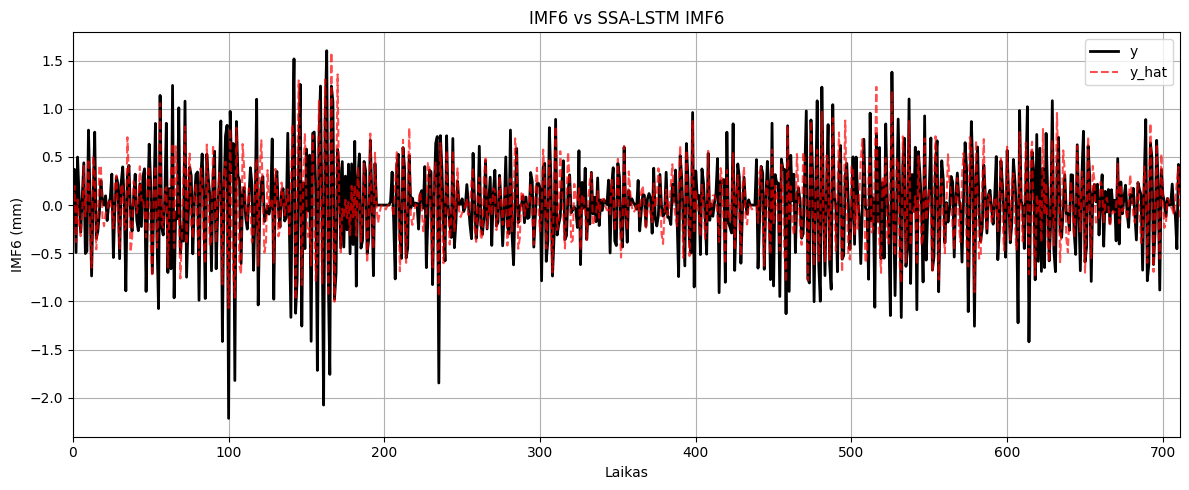

In [316]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       0.2381

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 4}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 4}

In [317]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=3),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [318]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0081        0.0058     +  0.4840
      2        0.0070        0.0061        0.2448
      3        0.0067        0.0054     +  0.2432
      4        0.0065        0.0082        0.2287
      5        0.0082        0.0059        0.2276
      6        0.0080        0.0056        0.2263
      7        0.0074        0.0064        0.2139
      8        0.0067        0.0056        0.2114
      9        0.0078        0.0069        0.2552
     10        0.0064        0.0064        0.2217
     11        0.0064        0.0050     +  0.2320
     12        0.0062        0.0045     +  0.2205
     13        0.0051        0.0045     +  0.2235
     14        0.0048        0.0053        0.2234
     15        0.0057        0.0058        0.2279
     16        0.0052        0.0042     +  0.2275
     17        0.0042        0.0042     +  0.2234
     18        0.0038        0.0049        0.2383


In [240]:
param_grid = {
    'window_size': [4, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0113        0.0082     +  0.1308
      2        0.0075        0.0060     +  0.1317
      3        0.0050        0.0043     +  0.1050
      4        0.0032        0.0032     +  0.0906
      5        0.0020        0.0021     +  0.0887
      6        0.0012        0.0016     +  0.0751
      7        0.0007        0.0012     +  0.0754
      8        0.0005        0.0011     +  0.0733
      9        0.0003        0.0010     +  0.0750
     10        0.0003        0.0010     +  0.0788
     11        0.0002        0.0009     +  0.0777
     12        0.0002        0.0009     +  0.0763
     13        0.0002        0.0009        0.0725
     14        0.0002        0.0009        0.0801
     15        0.0002        0.0010        0.0828
     16        0.0002        0.0009        0.0805
     17        0.0003        0.0009    

In [319]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true[11:]
y_pred_IMF7 = y_pred[11:]

RMSE:     0.0953
MAE:      0.0723
R2:       -1.0264
Spearman: 0.2427


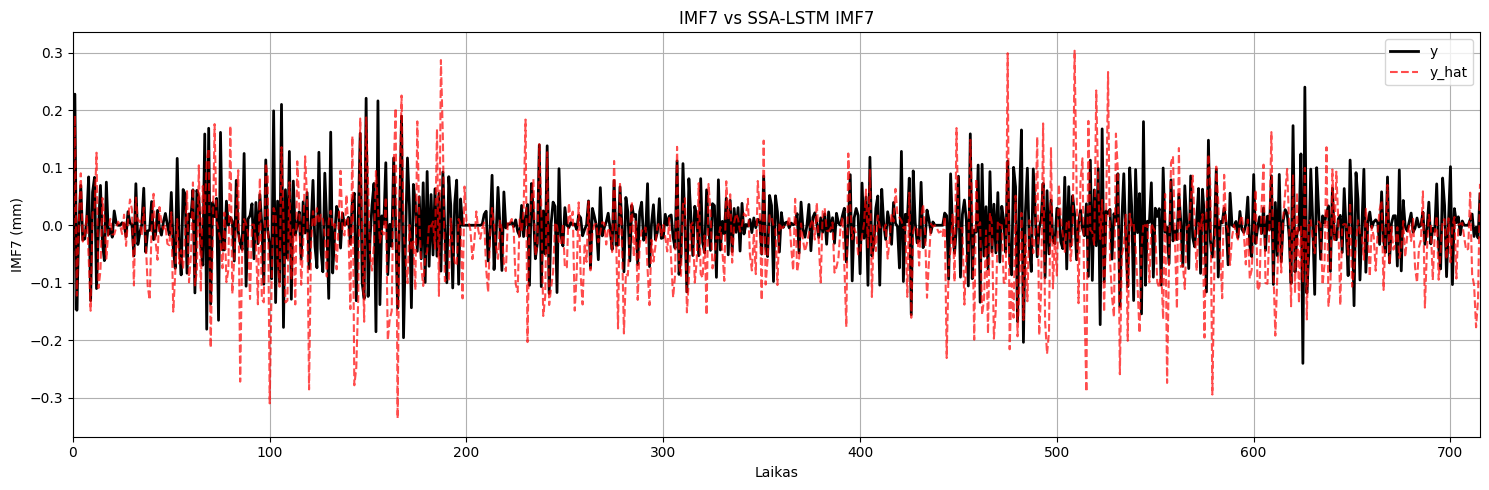

In [320]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.3563

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.1534

In [321]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [322]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0431        0.0464     +  0.2809
      2        0.0374        0.0360     +  0.1268
      3        0.0295        0.0311     +  0.1294
      4        0.0265        0.0335        0.1222
      5        0.0257        0.0299     +  0.1150
      6        0.0230        0.0290     +  0.1182
      7        0.0213        0.0286     +  0.1175
      8        0.0202        0.0275     +  0.1177
      9        0.0187        0.0273     +  0.1131
     10        0.0176        0.0264     +  0.1121
     11        0.0174        0.0278        0.1161
     12        0.0157        0.0271        0.1292
     13        0.0150        0.0276        0.1249
     14        0.0142        0.0283        0.1451
     15        0.0135        0.0263     +  0.1422
     16        0.0132        0.0265        0.1345
     17        0.0125        0.0270        0.1204
     18        0.0123        0.0258     +  0.1298


In [178]:
param_grid = {
    'window_size': [5],
    'module__hidden_dim': [64, 128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 12 candidates, totalling 24 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0517        0.0452     +  0.2545
      2        0.0478        0.0435     +  0.0888
      3        0.0453        0.0413     +  0.0918
      4        0.0421        0.0385     +  0.0954
      5        0.0380        0.0363     +  0.1027
      6        0.0339        0.0359     +  0.0951
      7        0.0298        0.0328     +  0.1078
      8        0.0242        0.0319     +  0.1037
      9        0.0217        0.0327        0.0957
     10        0.0194        0.0319     +  0.1038
     11        0.0159        0.0313     +  0.1105
     12        0.0130        0.0315        0.1178
     13        0.0111        0.0333        0.1038
     14        0.0096        0.0319        0.1116
     15        0.0074        0.0334        0.1053
     16        0.0063        0.0326        0.1094
     17        0.0047        0.0322    

In [323]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true[11:]
y_pred_IMF8 = y_pred[11:]

RMSE:     0.3462
MAE:      0.2535
R2:       -0.7064
Spearman: 0.2067


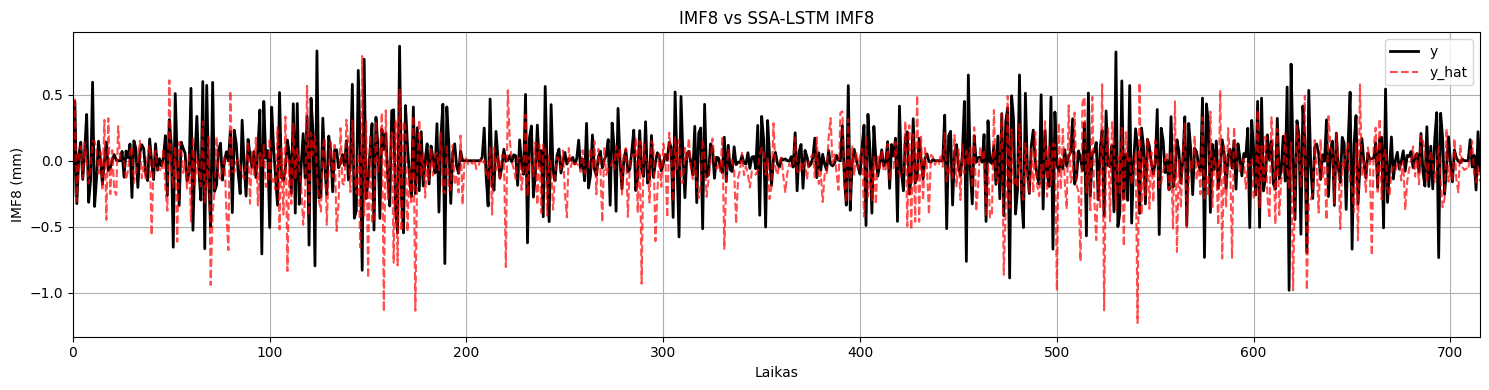

In [324]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SSA-LSTM rezultatai

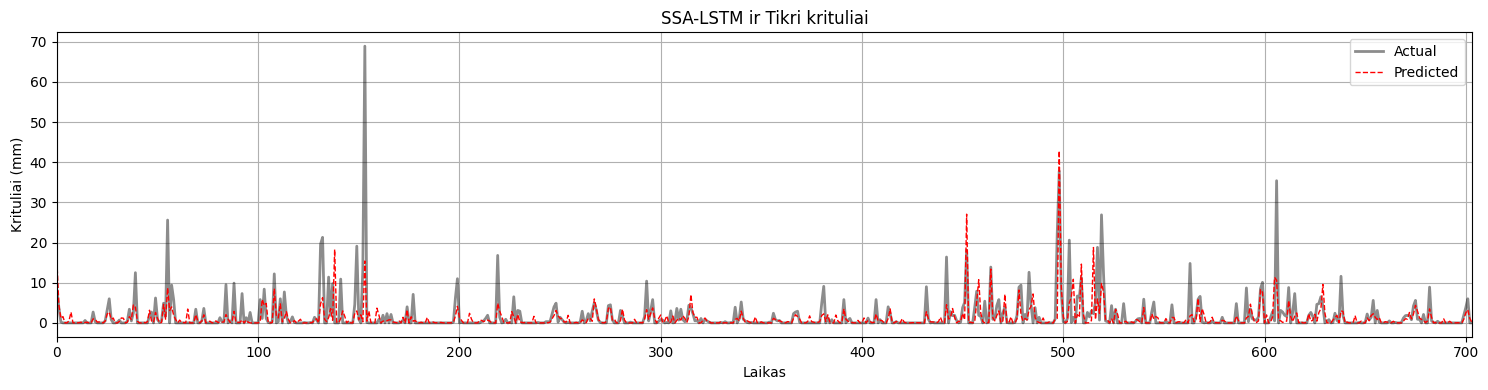

In [326]:
y_pred_IMF3_lvl = X_test_raw['IMF3'].values[14:] + y_pred_IMF3

y_pred_IMF4_lvl = X_test_raw['IMF4'].values[14:] + y_pred_IMF4

y_pred_IMF6_lvl = X_test_raw['IMF6'].values[14:] + y_pred_IMF6

y_true_final = np.expm1(y_original_imf['IMF1'].values.astype(float) + 
                        y_original_imf['IMF2'].values.astype(float) + 
                        y_original_imf['IMF3'].values.astype(float) + 
                        y_original_imf['IMF4'].values.astype(float) + 
                        y_original_imf['IMF5'].values.astype(float) + 
                        y_original_imf['IMF6'].values.astype(float) + 
                        y_original_imf['IMF7'].values.astype(float) + 
                        y_original_imf['IMF8'].values.astype(float))[14:]
y_pred_final = np.expm1(y_pred_IMF1[:] + y_pred_IMF2[:] + y_pred_IMF3_lvl[:] + y_pred_IMF4_lvl[:] + y_pred_IMF5 + y_pred_IMF6_lvl[:] + y_pred_IMF7 + y_pred_IMF8)[:].clip(min=0)
# y_actual_precipitation = data['missforest_precipitation'][(int(len(data)*0.8) + 14):-1].values
y_actual_precipitation = data['missforest_precipitation'][(2042 + 14):-1].values


plt.figure(figsize=(15, 4))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.45, color = 'black')
# plt.plot(y_true_final, label="True", linewidth=1.2, alpha = 0.8)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=1, color='red', linestyle='--')
plt.xlim(0, len(y_actual_precipitation) - 1)
plt.title("SSA-LSTM ir Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [327]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     3.6987
MAE:      1.4117
R2:       0.3759
Spearman: 0.6541


In [328]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final[:-1]))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final[:-1])
r2   = r2_score(y_actual_precipitation, y_pred_final[:-1])
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final[:-1])

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     3.7013
MAE:      1.4138
R2:       0.3758
Spearman: 0.6283


In [250]:
data[data['missforest_precipitation']==2.1][['missforest_precipitation', 'observationTime']]

,missforest_precipitation,observationTime
98,2.1,2018-10-07
113,2.1,2018-10-22
174,2.1,2018-12-22
367,2.1,2019-07-03
463,2.1,2019-10-07
834,2.1,2020-10-12
1215,2.1,2021-10-28
1272,2.1,2021-12-24
1492,2.1,2022-08-01
1711,2.1,2023-03-08


In [ ]:
results_df = pd.DataFrame({
    'observationTime': observation_times.iloc[(split_idx+14):-1].reset_index(drop=True),
    # 'actual': y_actual_precipitation,
    'SSA-LSTM': y_pred_final[:-1]
})
# results_df

results_df.to_csv('SSA-LSTM_pred.csv')

,observationTime,actual,SSA-LSTM
0,2024-02-27,8.1,15.455134
1,2024-02-28,3.7,4.297494
2,2024-02-29,0.2,1.131793
3,2024-03-01,0.0,1.565582
4,2024-03-02,0.0,0.000000
...,...,...,...
699,2026-01-26,1.9,0.886352
700,2026-01-27,3.8,2.472656
701,2026-01-28,6.0,3.272431
702,2026-01-29,0.0,1.106815
